
GRID: Best EER per System vs Condition
System            Baseline Face_C:zeroFace_C:neutral Face_C:unit Face_C:skip Face_G:zeroFace_G:neutral Face_G:unit Face_G:skip     LI:zero  LI:neutral     LI:unit     LI:skip     RI:zero  RI:neutral     RI:unit     RI:skip
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
S1                  3.3120      5.2275      5.2275      5.2275      5.2161      4.5173      4.5173      4.5173      4.5173           —           —           —           —           —           —           —           —
S2                  0.9690      8.1955      8.1955      8.1955      8.1974           —           —           —           —      4.5173      4.5173      4.5173      4.5173           —           —           —           —
S3                  0.2565      5.1075      5.1075      5.1075      5.1004      

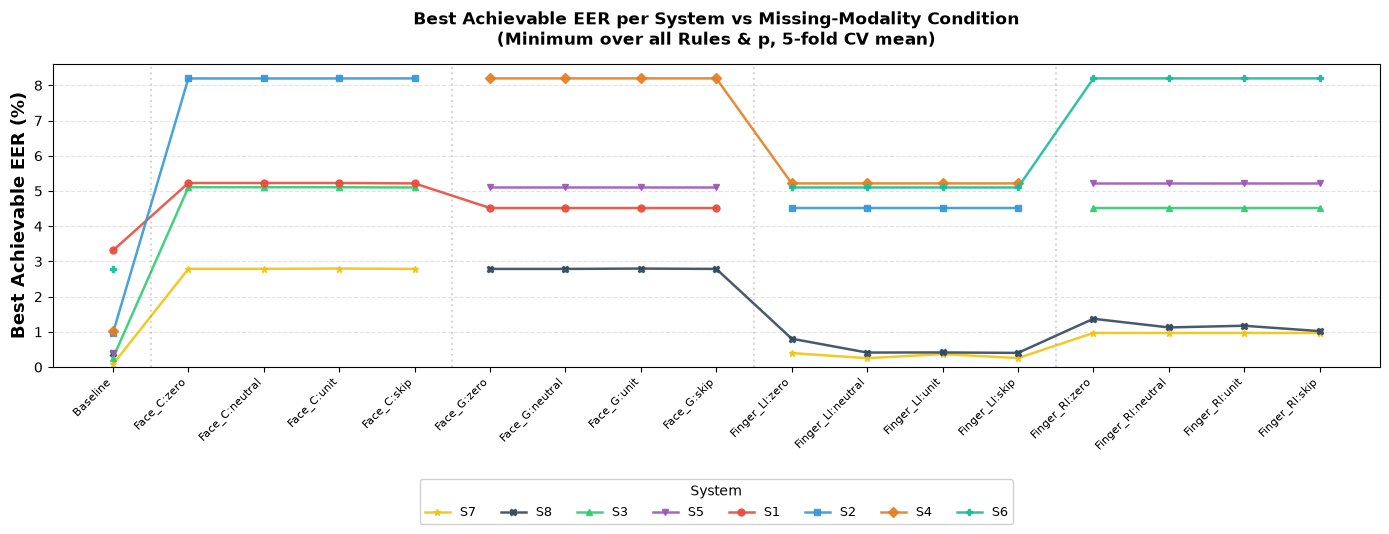

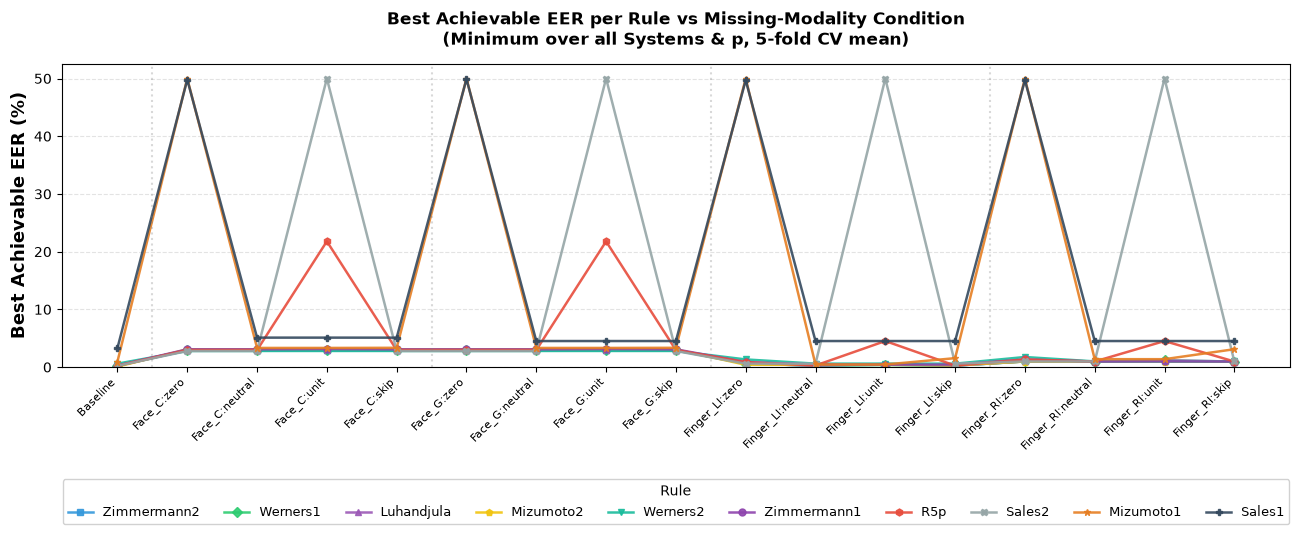

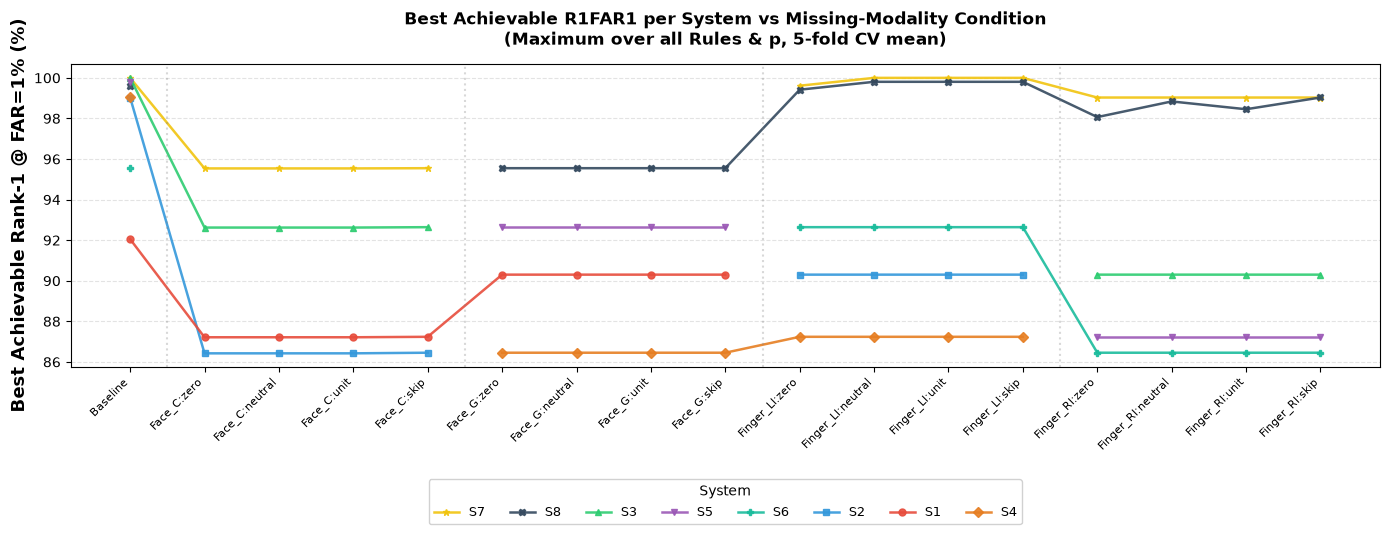

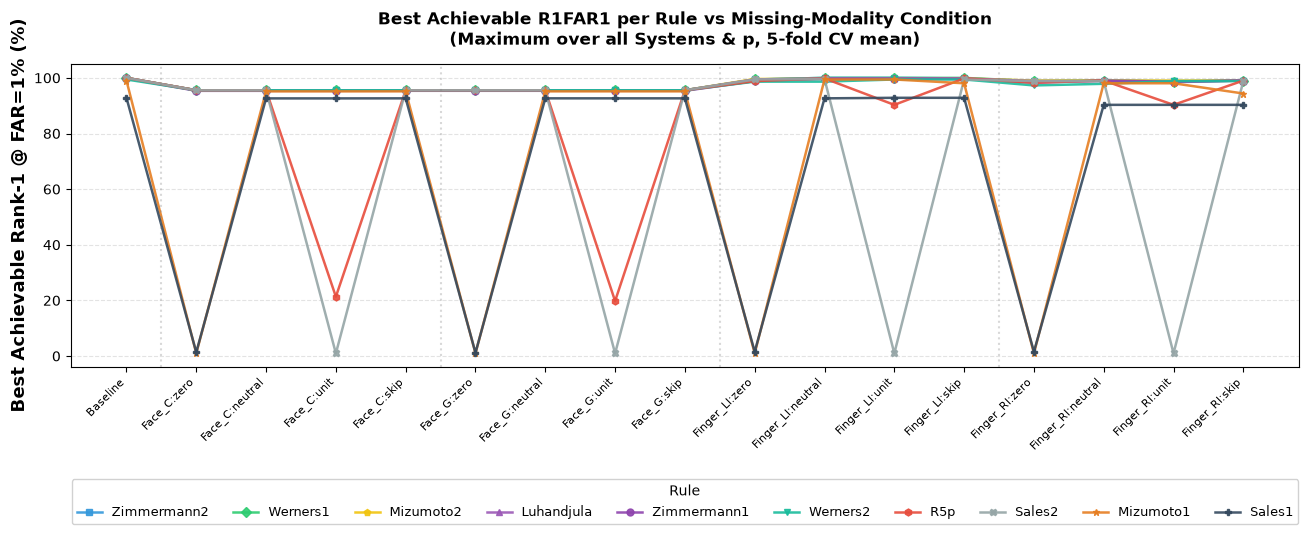


[DONE] All 4 figures and 4 grids generated.


In [1]:
#!/usr/bin/env python3
"""
Plot 4 figures from missing_modality_raw.xlsx:
  Fig A: Best Achievable EER  per System vs Missing Condition
  Fig B: Best Achievable EER  per Rule   vs Missing Condition
  Fig C: Best Achievable R1   per System vs Missing Condition
  Fig D: Best Achievable R1   per Rule   vs Missing Condition
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INPUT_FILE = './Results/missing_modality_raw.xlsx'

# ── Read & prepare ─────────────────────────────────────────────────────
df = pd.read_excel(INPUT_FILE)
df['EER']   = pd.to_numeric(df['EER'],   errors='coerce') * 100
df['Rank1'] = pd.to_numeric(df['Rank1'], errors='coerce') * 100
df.rename(columns={'Rank1': 'R1FAR1'}, inplace=True)

systems = ['S1','S2','S3','S4','S5','S6','S7','S8']
rules   = sorted(df['Rule'].unique())

# Condition label
df['Condition'] = df.apply(
    lambda r: 'Baseline' if r['Fill'] == 'baseline'
    else f"{r['Missing']}:{r['Fill']}", axis=1)

# Ordered x-axis: grouped by missing modality
all_fills = ['zero', 'neutral', 'unit', 'skip']
all_mods  = ['Face_C', 'Face_G', 'Finger_LI', 'Finger_RI']
condition_order = ['Baseline']
for mod in all_mods:
    for fill in all_fills:
        condition_order.append(f"{mod}:{fill}")
cond_idx = {c: i for i, c in enumerate(condition_order)}

# Mean over folds per (System, Rule, Condition, p)
agg = (df.groupby(['System', 'Rule', 'Condition', 'p'])
         .agg(EER=('EER', 'mean'), R1FAR1=('R1FAR1', 'mean'))
         .reset_index())

# ── Best-achievable envelopes ──────────────────────────────────────────
best_eer_sys  = agg.groupby(['System','Condition'])['EER'].min().reset_index()
best_eer_rule = agg.groupby(['Rule',  'Condition'])['EER'].min().reset_index()
best_r1_sys   = agg.groupby(['System','Condition'])['R1FAR1'].max().reset_index()
best_r1_rule  = agg.groupby(['Rule',  'Condition'])['R1FAR1'].max().reset_index()

# ── Colours & markers ──────────────────────────────────────────────────
sys_colors = {
    'S1':'#E74C3C','S2':'#3498DB','S3':'#2ECC71','S4':'#E67E22',
    'S5':'#9B59B6','S6':'#1ABC9C','S7':'#F1C40F','S8':'#34495E'}
sys_markers = {
    'S1':'o','S2':'s','S3':'^','S4':'D',
    'S5':'v','S6':'P','S7':'*','S8':'X'}
rule_colors = {
    'Zimmermann1':'#8E44AD','Zimmermann2':'#3498DB',
    'Luhandjula':'#9B59B6', 'Werners1':'#2ECC71',
    'Werners2':'#1ABC9C',   'Sales1':'#34495E',
    'Sales2':'#95A5A6',     'Mizumoto1':'#E67E22',
    'Mizumoto2':'#F1C40F',  'R5p':'#E74C3C'}
rule_markers = {
    'Zimmermann1':'o','Zimmermann2':'s',
    'Luhandjula':'^','Werners1':'D',
    'Werners2':'v','Sales1':'P',
    'Sales2':'X','Mizumoto1':'*',
    'Mizumoto2':'p','R5p':'h'}

# ── Generic plotting function ──────────────────────────────────────────
def plot_envelope(data, group_col, y_col, colors, markers,
                  ylabel, title, fname, lower_better=True):
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor('white')

    groups = sorted(data[group_col].unique())
    # Sort legend by overall performance
    if lower_better:
        groups = sorted(groups,
                        key=lambda g: data[data[group_col]==g][y_col].mean())
    else:
        groups = sorted(groups,
                        key=lambda g: -data[data[group_col]==g][y_col].mean())

    xs_full = np.arange(len(condition_order))
    for g in groups:
        sub = data[data[group_col] == g]
        ys = np.full(len(condition_order), np.nan)
        for _, row in sub.iterrows():
            idx = cond_idx.get(row['Condition'])
            if idx is not None:
                ys[idx] = row[y_col]
        ax.plot(xs_full, ys,
                color=colors.get(g, '#95A5A6'),
                marker=markers.get(g, 'o'),
                markersize=5, linewidth=1.8, label=g, alpha=0.9)

    # Vertical separators between modality groups
    for sep in [0.5, 4.5, 8.5, 12.5]:
        ax.axvline(x=sep, color='gray', linestyle=':', alpha=0.3)

    ax.set_xticks(xs_full)
    ax.set_xticklabels(condition_order, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(ylabel, fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=14)
    ax.grid(True, axis='y', linestyle='--', alpha=0.35)
    if lower_better:
        ax.set_ylim(bottom=0)

    ncol = min(len(groups), 10)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.35),
              ncol=ncol, fontsize=9, framealpha=0.9,
              title=group_col, title_fontsize=10)

    plt.tight_layout()
    plt.savefig(f'{fname}.png', dpi=200, bbox_inches='tight')
    plt.savefig(f'{fname}.pdf', bbox_inches='tight')
    plt.show()

# ── Print grids ────────────────────────────────────────────────────────
def print_grid(data, group_col, y_col, label, fmt='.4f'):
    print(f"\n{'='*80}")
    print(f"GRID: {label}")
    print(f"{'='*80}")
    short = [c if len(c) <= 12 else c.replace('Finger_','') for c in condition_order]
    header = f"{group_col:<14}" + "".join([f"{s}".rjust(12) for s in short])
    print(header)
    print("-" * (14 + 12 * len(condition_order)))
    for g in sorted(data[group_col].unique()):
        row = f"{g:<14}"
        sub = data[data[group_col] == g].set_index('Condition')
        for c in condition_order:
            if c in sub.index:
                row += f"{sub.loc[c, y_col]:{fmt}}".rjust(12)
            else:
                row += f"{'—':>12}"
        print(row)
    print("=" * 80)

print_grid(best_eer_sys,  'System', 'EER',   'Best EER per System vs Condition')
print_grid(best_eer_rule, 'Rule',   'EER',   'Best EER per Rule vs Condition')
print_grid(best_r1_sys,   'System', 'R1FAR1','Best R1FAR1 per System vs Condition')
print_grid(best_r1_rule,  'Rule',   'R1FAR1','Best R1FAR1 per Rule vs Condition')

# ═══════════════════════════════════════════════════════════════════════
#  FIG A — Best EER per System
# ═══════════════════════════════════════════════════════════════════════
plot_envelope(best_eer_sys, 'System', 'EER',
              sys_colors, sys_markers,
              'Best Achievable EER (%)',
              'Best Achievable EER per System vs Missing-Modality Condition\n'
              '(Minimum over all Rules & p, 5-fold CV mean)',
              'FigA_BestEER_per_System', lower_better=True)

# ═══════════════════════════════════════════════════════════════════════
#  FIG B — Best EER per Rule
# ═══════════════════════════════════════════════════════════════════════
plot_envelope(best_eer_rule, 'Rule', 'EER',
              rule_colors, rule_markers,
              'Best Achievable EER (%)',
              'Best Achievable EER per Rule vs Missing-Modality Condition\n'
              '(Minimum over all Systems & p, 5-fold CV mean)',
              'FigB_BestEER_per_Rule', lower_better=True)

# ═══════════════════════════════════════════════════════════════════════
#  FIG C — Best R1FAR1 per System
# ═══════════════════════════════════════════════════════════════════════
plot_envelope(best_r1_sys, 'System', 'R1FAR1',
              sys_colors, sys_markers,
              'Best Achievable Rank-1 @ FAR=1% (%)',
              'Best Achievable R1FAR1 per System vs Missing-Modality Condition\n'
              '(Maximum over all Rules & p, 5-fold CV mean)',
              'FigC_BestR1FAR1_per_System', lower_better=False)

# ═══════════════════════════════════════════════════════════════════════
#  FIG D — Best R1FAR1 per Rule
# ═══════════════════════════════════════════════════════════════════════
plot_envelope(best_r1_rule, 'Rule', 'R1FAR1',
              rule_colors, rule_markers,
              'Best Achievable Rank-1 @ FAR=1% (%)',
              'Best Achievable R1FAR1 per Rule vs Missing-Modality Condition\n'
              '(Maximum over all Systems & p, 5-fold CV mean)',
              'FigD_BestR1FAR1_per_Rule', lower_better=False)

print("\n[DONE] All 4 figures and 4 grids generated.")